In [1]:
!pip install -q "monai[nibabel]"

import os
import re
import json

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
from monai.data import DataLoader

from sklearn.model_selection import train_test_split, KFold

from monai.data import Dataset, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    RandCropByPosNegLabeld, RandFlipd, EnsureTyped, AsDiscrete,
)
from monai.networks.nets import UNet, AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.1 MB/s eta 0:00:00
Using device: cuda


In [2]:
# Check what hardware this session actually has
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

BASE_DIR = "/kaggle/input/datasets/thisisrick25/medical-segmentation-decathlon-brain-tumour"
for root, dirs, files in os.walk(BASE_DIR):
    depth = root.replace(BASE_DIR, "").count(os.sep)
    if depth > 2:
        continue
    print("  " * depth + os.path.basename(root) + "/")


DATA_DIR = os.path.join(BASE_DIR, "Task01_BrainTumour")

# Round-trip test: can we save and reload a checkpoint?
dummy = {"epoch": 0, "state_dict": {}}
torch.save(dummy, "/kaggle/working/checkpoint_test.pt")
reloaded = torch.load("/kaggle/working/checkpoint_test.pt")
print("Checkpoint reload OK:", reloaded["epoch"] == 0)

GPU available: True
GPU name: Tesla T4
medical-segmentation-decathlon-brain-tumour/
  Task01_BrainTumour/
    imagesTs/
    labelsTr/
    imagesTr/
Checkpoint reload OK: True


### Data Exploration 

In [3]:
import os
import re
import nibabel as nib
import numpy as np

IMAGES_DIR = os.path.join(DATA_DIR, "imagesTr")
LABELS_DIR = os.path.join(DATA_DIR, "labelsTr")

def is_real_file(filename):
    # skip macOS "._" junk files
    return not filename.startswith("._")

def patient_id(filename):
    match = re.match(r"(BRATS_\d+)", filename)
    return match.group(1) if match else None

image_files = {patient_id(f): os.path.join(IMAGES_DIR, f)
               for f in os.listdir(IMAGES_DIR) if is_real_file(f)}
label_files = {patient_id(f): os.path.join(LABELS_DIR, f)
               for f in os.listdir(LABELS_DIR) if is_real_file(f)}
# matched by patient ID, not filename (extensions differ)

patient_ids = sorted(set(image_files) & set(label_files))
print(f"Found {len(patient_ids)} patients with both an image and a label file")

missing_labels = set(image_files) - set(label_files)
missing_images = set(label_files) - set(image_files)
if missing_labels:
    print("Image but no label:", sorted(missing_labels))
if missing_images:
    print("Label but no image:", sorted(missing_images))

issues = []
for pid in patient_ids:
    try:
        image = nib.load(image_files[pid])
        label = nib.load(label_files[pid])
    except Exception as error:
        issues.append((pid, f"failed to load: {error}"))
        continue

    if image.shape[-1] != 4:
        issues.append((pid, f"expected 4 channels, got shape {image.shape}"))

    label_classes = set(np.unique(label.get_fdata()))
    if not label_classes.issubset({0, 1, 2, 3}):
        issues.append((pid, f"unexpected label values: {label_classes}"))

print(f"Checked {len(patient_ids)} patients, found {len(issues)} issues")
for pid, problem in issues:
    print(pid, "-", problem)

Found 484 patients with both an image and a label file
Checked 484 patients, found 0 issues


Background                       4,271,154,985 voxels  (98.843%)
Oedema                              31,456,687 voxels  ( 0.728%)
Non-Enhancing Tumour                 8,731,567 voxels  ( 0.202%)
Enhancing Tumour                     9,808,761 voxels  ( 0.227%)


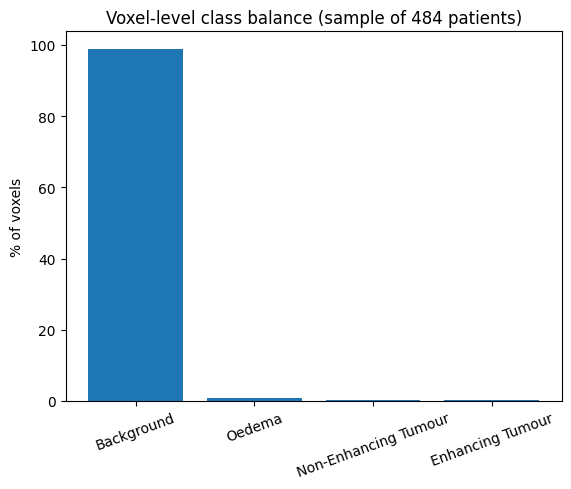

In [4]:
"""
Voxel-level class balance for the entire dataset based on patient_ids
"""

#0=background, 1=edema, 2=non-enhancing tumor, 3=enhancing tumour.
class_names = ["Background", "Oedema", "Non-Enhancing Tumour", "Enhancing Tumour"]
voxel_counts = np.zeros(4, dtype=np.int64)

sample_size = len(patient_ids)
sample_ids = patient_ids[:sample_size]
for pid in sample_ids:
    label = nib.load(label_files[pid]).get_fdata()
    values, counts = np.unique(label, return_counts=True)
    for v, c in zip(values, counts):
        voxel_counts[int(v)] += c

total_voxels = voxel_counts.sum()
percentages = 100 * voxel_counts / total_voxels

for name, count, pct in zip(class_names, voxel_counts, percentages):
    print(f"{name:30s} {count:>15,d} voxels  ({pct:6.3f}%)")

plt.bar(class_names, percentages)
plt.ylabel("% of voxels")
plt.title(f"Voxel-level class balance (sample of {sample_size} patients)")
plt.xticks(rotation=20)
plt.show()

### Train/val/test split

In [5]:
from sklearn.model_selection import train_test_split

"""
Two-stage split at patient-level, so no patient's
scans ever appear in more than one of these three sets:
"""

# test set
train_val_ids, test_ids = train_test_split(
    patient_ids, test_size=0.15, random_state=42
)

# train/val set
train_ids, val_ids = train_test_split(
    train_val_ids, test_size= 0.15/0.85, random_state=42
)

print(f"train: {len(train_ids)}  val: {len(val_ids)}  test: {len(test_ids)}")

train: 338  val: 73  test: 73


### Preprocessing Pipeline

FLAIR before -> mean:   516.27 std:   211.65   |   after -> mean:  0.000 std:  1.000
T1    before -> mean:   780.63 std:   206.55   |   after -> mean: -0.000 std:  1.000
T1ce  before -> mean:   728.44 std:   239.42   |   after -> mean: -0.000 std:  1.000
T2    before -> mean:   471.84 std:   211.00   |   after -> mean: -0.000 std:  1.000


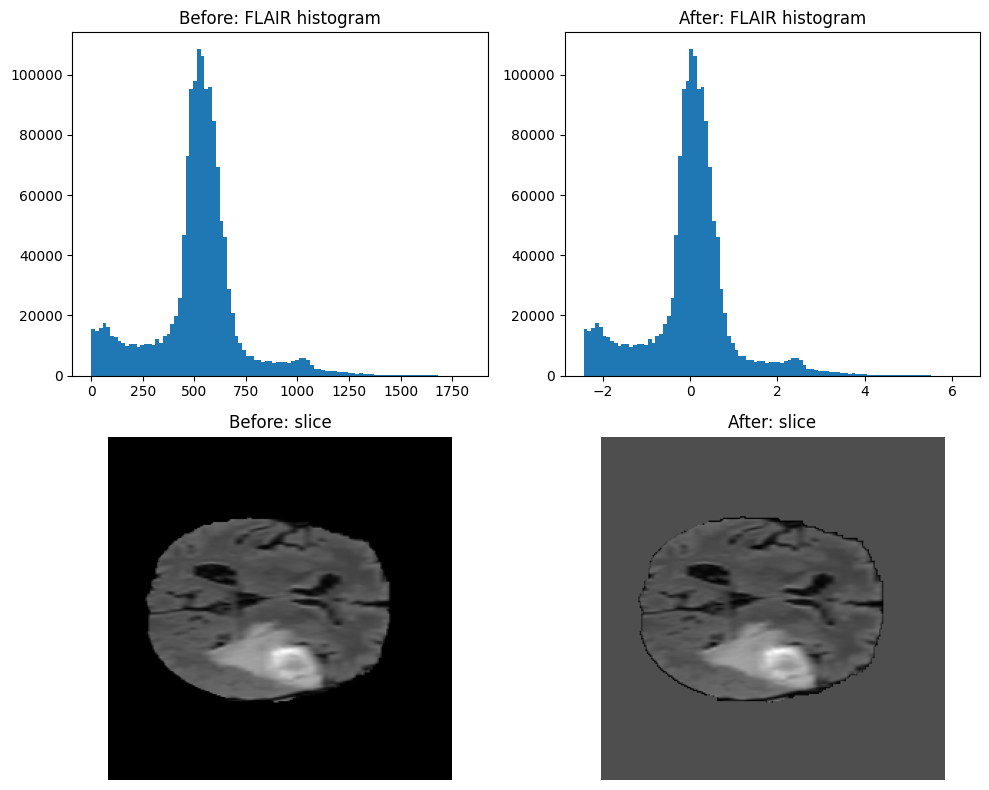

In [6]:
# Normalization

from monai.transforms import NormalizeIntensity
import numpy as np
import matplotlib.pyplot as plt

# mean/std per modality
normalise = NormalizeIntensity(nonzero=True, channel_wise=True)

raw_volume = nib.load(image_files[patient_ids[0]]).get_fdata()   # (H, W, D, 4)
volume_channel_first = np.moveaxis(raw_volume, -1, 0)             # (4, H, W, D)

normalised = normalise(volume_channel_first.copy())

modality_names = ["FLAIR", "T1", "T1ce", "T2"]
for i, name in enumerate(modality_names):
    before = volume_channel_first[i]
    after = normalised[i]
    print(f"{name:5s} before -> mean: {before[before > 0].mean():8.2f} std: {before[before > 0].std():8.2f}"
          f"   |   after -> mean: {after[after != 0].mean():6.3f} std: {after[after != 0].std():6.3f}")

# visualize a modality (FLAIR)
mod_idx = 0
before_mod = volume_channel_first[mod_idx]
after_mod = normalised[mod_idx]
slice_idx = before_mod.shape[-1] // 2

# count of how many voxels fall into each intensity bucket across the whole 3D volume
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(before_mod[before_mod > 0].ravel(), bins=100)
axes[0, 0].set_title(f"Before: {modality_names[mod_idx]} histogram")
axes[0, 1].hist(after_mod[after_mod != 0].ravel(), bins=100)
axes[0, 1].set_title(f"After: {modality_names[mod_idx]} histogram")

# slice sanity check 
axes[1, 0].imshow(before_mod[..., slice_idx], cmap="gray")
axes[1, 0].set_title("Before: slice"); axes[1, 0].axis("off")
axes[1, 1].imshow(after_mod[..., slice_idx], cmap="gray")
axes[1, 1].set_title("After: slice"); axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

### Dataset/Dataloader Design

In [7]:
def make_data_dicts(ids):
    return [
        {"image": image_files[pid], "label": label_files[pid]}
        for pid in ids
    ]

train_files = make_data_dicts(train_ids)
val_files   = make_data_dicts(val_ids)
test_files  = make_data_dicts(test_ids)

# training: random patch crop + augmentation
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"], channel_dim=-1),
    EnsureChannelFirstd(keys=["label"], channel_dim="no_channel"),
    NormalizeIntensityd(keys=["image"], channel_wise=True, nonzero=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1, neg=1,
        num_samples=2,
    ),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    EnsureTyped(keys=["image", "label"]),
])

# val/test: no cropping or augmentation
eval_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"], channel_dim=-1),
    EnsureChannelFirstd(keys=["label"], channel_dim="no_channel"),
    NormalizeIntensityd(keys=["image"], channel_wise=True, nonzero=True),
    EnsureTyped(keys=["image", "label"]),
])

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds   = Dataset(data=val_files,   transform=eval_transforms)
test_ds  = Dataset(data=test_files,  transform=eval_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2)
# batch_size=1: full-size volumes, one at a time via sliding-window inference
val_loader  = DataLoader(val_ds,  batch_size=1, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

nvImageCodec is not available; skipping pydicom decoder plugin registration.
/usr/local/lib/python3.12/dist-packages/monai/data/image_reader.py:1166: UserWarning: NvImgCodecPydicomReader: nvImageCodec decoder plugin did not register successfully. Falling back to default pydicom decoders.
  warnings.warn(
nvImageCodec is not available; skipping pydicom decoder plugin registration.


In [8]:
print(type(train_loader), type(val_loader), type(test_loader))
batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"].shape)

<class 'monai.data.dataloader.DataLoader'> <class 'monai.data.dataloader.DataLoader'> <class 'monai.data.dataloader.DataLoader'>
torch.Size([4, 4, 96, 96, 96]) torch.Size([4, 1, 96, 96, 96])


### CNN/Segmentation Model Implementation